## Avazu dataset - exploratory data analysis (EDA)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

In [2]:
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

### Reading data 

We read first 1 000 000 rows - just not for not burdening our RAMs

In [21]:
df = pd.read_csv('train.csv', nrows=1000000)

print(f"Data shape: {df.shape[0]} rows, {df.shape[1]} columns.\n")

Data shape: 1000000 rows, 24 columns.



In [25]:
print("Columns list:")
print(df.columns.tolist())
print("-" * 50)

print("\nStructure:")
df.info()

display(df.head()) 

Columns list:
['id', 'click', 'hour', 'C1', 'banner_pos', 'site_id', 'site_domain', 'site_category', 'app_id', 'app_domain', 'app_category', 'device_id', 'device_ip', 'device_model', 'device_type', 'device_conn_type', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21']
--------------------------------------------------

Structure:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 24 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   id                1000000 non-null  float64
 1   click             1000000 non-null  int64  
 2   hour              1000000 non-null  int64  
 3   C1                1000000 non-null  int64  
 4   banner_pos        1000000 non-null  int64  
 5   site_id           1000000 non-null  object 
 6   site_domain       1000000 non-null  object 
 7   site_category     1000000 non-null  object 
 8   app_id            1000000 non-null  object 
 9   app_dom

,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,app_category,device_id,device_ip,device_model,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21
0,1.000009e+18,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,ddd2926e,44956a24,1,2,15706,320,50,1722,0,35,-1,79
1,1.000017e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,96809ac8,711ee120,1,0,15704,320,50,1722,0,35,100084,79
2,1.000037e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,b3cf8def,8a4875bd,1,0,15704,320,50,1722,0,35,100084,79
3,1.000064e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,e8275b8f,6332421a,1,0,15706,320,50,1722,0,35,100084,79
4,1.000068e+19,0,14102100,1005,1,fe8cc448,9166c161,0569f928,ecad2386,7801e8d9,07d7df22,a99f214a,9644d0bf,779d90c2,1,0,18993,320,50,2161,0,35,-1,157


### Analysis of a target variable `click`

No click (0): 83.98%
Click (1): 16.02%



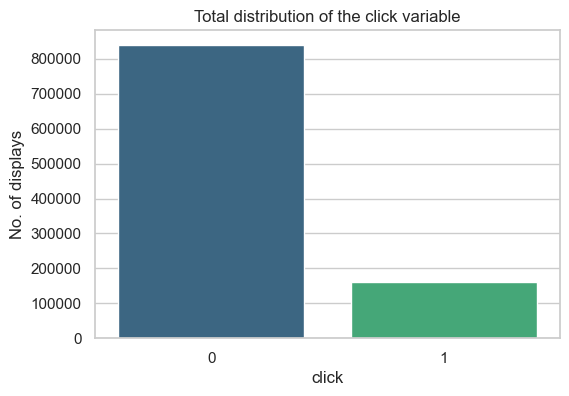

In [19]:
click_dist = df['click'].value_counts(normalize=True) * 100
print(f"No click (0): {click_dist[0]:.2f}%")
print(f"Click (1): {click_dist[1]:.2f}%\n")

plt.figure(figsize=(6, 4))
sns.countplot(x='click', hue='click', data=df, palette='viridis', legend=False)
plt.title('Total distribution of the click variable')
plt.ylabel('No. of displays')
plt.show()

### Feature engineering + high cardinality analysis

Here, we would like to choose 10 top columns with the greatest number of unique values 

In [28]:
# hour is YYMMDDHH
df['hour_str'] = df['hour'].astype(str)
df['day'] = df['hour_str'].str[4:6].astype(int)
df['hour_of_day'] = df['hour_str'].str[6:8].astype(int)

print("Feature cardinality")
cardinality = df.nunique().sort_values(ascending=False)
print(cardinality.head(50))

Feature cardinality
id                  1000000
device_ip            313002
device_id             83431
device_model           4581
app_id                 2309
site_id                2075
site_domain            2030
C14                     606
C17                     162
C20                     161
app_domain              156
C19                      41
C21                      35
app_category             23
site_category            21
C16                       9
C15                       8
banner_pos                7
C1                        7
hour_of_day               6
hour                      6
hour_str                  6
device_conn_type          4
C18                       4
device_type               4
click                     2
day                       1
dtype: int64


### Click-through rate (CTR) analysis 

In this section, we would like to present three visualizations:
- Plot A: mean CTR depending on the hour time (throughout the day)
- Plot B: distribution of clicks depending on the device type
- Plot C: influence of the banner position on CTR

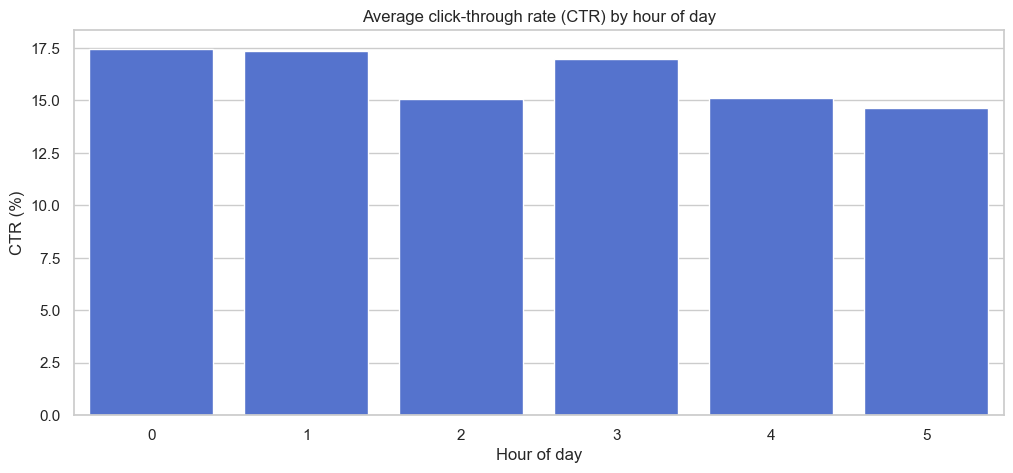

In [ ]:
# plot A
hourly_ctr = df.groupby('hour_of_day')['click'].mean().reset_index()
hourly_ctr['click'] = hourly_ctr['click'] * 100

plt.figure(figsize=(12, 5))
sns.barplot(x='hour_of_day', y='click', data=hourly_ctr, color='royalblue')
plt.title('Average click-through rate (CTR) by hour of day')
plt.ylabel('CTR (%)')
plt.xlabel('Hour of day')
plt.show()

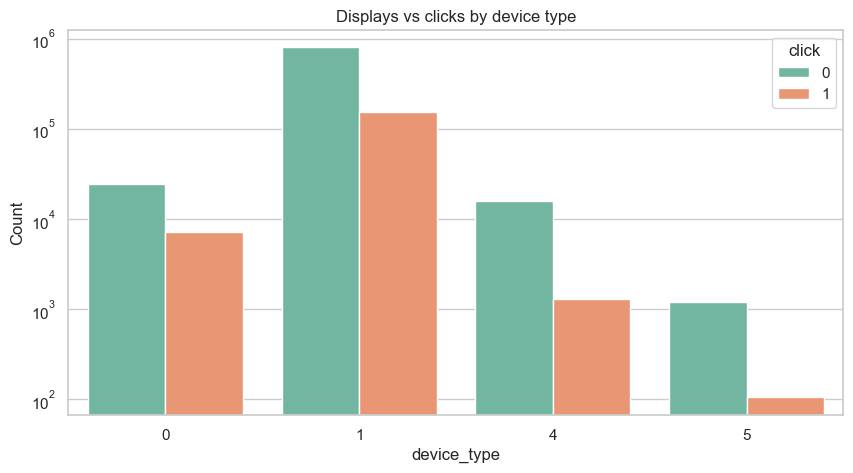

In [17]:
# plot B
plt.figure(figsize=(10, 5))
sns.countplot(x='device_type', hue='click', data=df, palette='Set2')
plt.title('Displays vs clicks by device type')
plt.yscale('log') # log scale as there is a dominance of one class
plt.ylabel('Count')
plt.show()

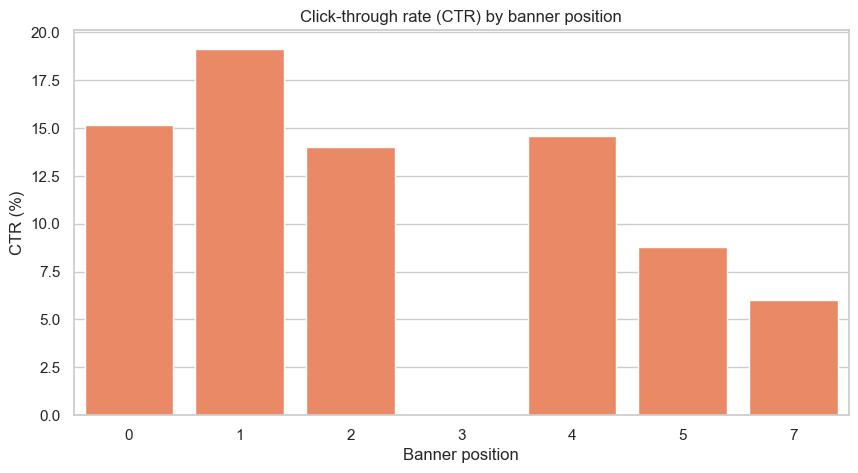

In [18]:
# plot C
banner_ctr = df.groupby('banner_pos')['click'].mean().reset_index()
banner_ctr['click'] = banner_ctr['click'] * 100

plt.figure(figsize=(10, 5))
sns.barplot(x='banner_pos', y='click', data=banner_ctr, color='coral')
plt.title('Click-through rate (CTR) by banner position')
plt.ylabel('CTR (%)')
plt.xlabel('Banner position')
plt.show()